<a href="https://colab.research.google.com/github/dani503sv/parcial4_DanielAmaya_2513232022/blob/main/ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 2: Análisis de Correlación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/dani503sv/parcial4_DanielAmaya_2513232022/refs/heads/main/Archivos/clave_F_correlacion.csv"

importan las librerías necesarias para cargar, explorar y analizar el archivo de correlación. También se define la URL del dataset alojado en GitHub

In [2]:
df = pd.read_csv(url)
df.head(10)

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,48,783,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,31,1187,7,65.26,3.50,8,7,28.48,386.42
5,F-C0006,45,667,9,38.08,8.24,1,7,29.87,430.45
6,F-C0007,37,1144,6,68.62,5.77,4,6,27.91,427.75
7,F-C0008,37,1367,7,77.70,5.14,5,4,31.62,552.23
8,F-C0009,35,1269,8,45.69,7.45,1,7,16.79,462.70
9,F-C0010,37,1184,11,82.26,6.87,4,8,16.66,804.66


Se carga correctamente el archivo CSV. Cada fila representa un cliente y cada columna describe una métrica relacionada con edad, ingresos, comportamiento de compra, satisfacción, reclamos, uso de la app, tiempo de respuesta y consumo total.

In [3]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (246, 10)

Columnas del dataset:
['cliente_id', 'edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']

Tipos de datos:
cliente_id             object
edad                    int64
ingresos_mensuales      int64
frecuencia_compra       int64
ticket_promedio       float64
satisfaccion          float64
reclamos                int64
uso_app                 int64
tiempo_respuesta      float64
consumo_total         float64
dtype: object


Aquí se revisa la estructura general del dataset, incluyendo la cantidad de filas y columnas, los nombres de las variables y sus tipos de datos. Esto permite confirmar cuáles variables pueden participar en el análisis de correlación.

In [4]:
variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

print("Variables numéricas identificadas:")
print(variables_numericas)

Variables numéricas identificadas:
['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']


El análisis de correlación solo se aplica a variables numéricas, por lo que primero se identifican todas las columnas cuantitativas. En este dataset aparecen métricas como edad, ingresos mensuales, frecuencia de compra, ticket promedio, satisfacción, reclamos, uso de la aplicación, tiempo de respuesta y consumo total.

In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados exactos:")
print(df.duplicated().sum())

Valores nulos por columna:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Registros duplicados exactos:
1


Se revisan valores nulos y registros duplicados para evaluar la calidad del dataset antes de calcular correlaciones. En el archivo se observan valores faltantes al menos en satisfaccion y tiempo_respuesta, y también existe por lo menos un registro repetido exacto

In [6]:
df_limpio = df.copy()

df_limpio = df_limpio.drop_duplicates()

for col in variables_numericas:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

df_limpio[variables_numericas] = df_limpio[variables_numericas].fillna(df_limpio[variables_numericas].median())

print("Dimensiones después de limpieza:", df_limpio.shape)
print("\nNulos después de limpieza:")
print(df_limpio[variables_numericas].isnull().sum())

Dimensiones después de limpieza: (245, 10)

Nulos después de limpieza:
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       0
satisfaccion          0
reclamos              0
uso_app               0
tiempo_respuesta      0
consumo_total         0
dtype: int64


En esta etapa se eliminan duplicados y se completan los valores faltantes usando la mediana de cada variable numérica. Esta decisión permite conservar los registros y evitar que los nulos afecten la matriz de correlación.

In [7]:
resumen = df_limpio[variables_numericas].describe().T
resumen

,count,mean,std,min,25%,50%,75%,max
edad,245.0,38.771429,10.233583,18.00,31.00,39.000,46.00,62.00
ingresos_mensuales,245.0,1119.440816,263.971282,484.00,926.00,1117.000,1298.00,1838.00
frecuencia_compra,245.0,7.902041,3.294089,2.00,6.00,8.000,9.00,32.00
ticket_promedio,245.0,66.285939,15.390429,27.13,56.50,66.085,75.95,114.02
satisfaccion,245.0,7.527510,1.339705,3.02,6.79,7.740,8.51,10.00
reclamos,245.0,1.538776,1.751910,0.00,0.00,1.000,2.00,9.00
uso_app,245.0,5.636735,2.071142,0.00,4.00,6.000,7.00,10.00
tiempo_respuesta,245.0,21.045082,6.727680,5.00,16.60,20.485,25.47,43.50
consumo_total,245.0,524.958122,223.539399,145.72,377.18,514.740,627.84,2026.66


Este resumen estadístico permite revisar consistencia general del dataset. Aquí puede observarse mínimos, máximos, medias y desviaciones estándar para evaluar si los valores lucen razonables según el contexto del negocio

In [8]:
Q1 = df_limpio[variables_numericas].quantile(0.25)
Q3 = df_limpio[variables_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_limpio[variables_numericas] < (Q1 - 1.5 * IQR)) |
            (df_limpio[variables_numericas] > (Q3 + 1.5 * IQR)))

outliers.sum().sort_values(ascending=False)

,0
reclamos,8
tiempo_respuesta,4
satisfaccion,4
consumo_total,4
frecuencia_compra,3
ticket_promedio,3
edad,0
ingresos_mensuales,0
uso_app,0


Para detectar valores atípicos se utiliza el rango intercuartílico. Esto ayuda a identificar variables con observaciones extremas que podrían influir en la interpretación de las correlaciones, especialmente en métricas como frecuencia de compra, consumo total o tiempo de respuesta.



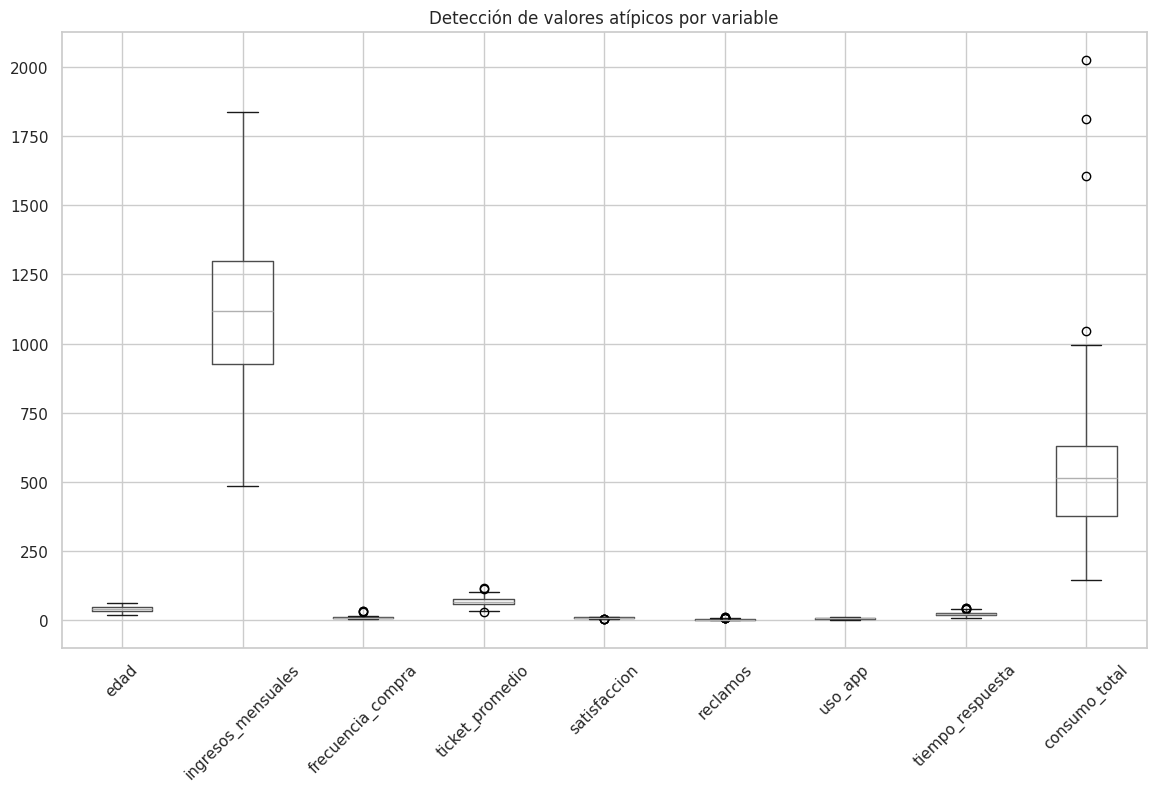

In [9]:
plt.figure(figsize=(14,8))
df_limpio[variables_numericas].boxplot(rot=45)
plt.title("Detección de valores atípicos por variable")
plt.show()

El gráfico de cajas permite visualizar de forma clara la dispersión y los posibles outliers de cada variable numérica. Esta evidencia fortalece la revisión de consistencia general solicitada en el parcial.

In [10]:
corr_matrix = df_limpio[variables_numericas].corr(numeric_only=True)
corr_matrix

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.074459,0.073616,0.144897,-0.017257,0.046902,0.060069,0.014992,0.098105
ingresos_mensuales,0.074459,1.000000,0.068764,0.659962,-0.056680,0.004270,-0.040493,0.175441,0.321616
frecuencia_compra,0.073616,0.068764,1.000000,0.172632,0.124388,-0.068936,0.400843,-0.083792,0.897235
ticket_promedio,0.144897,0.659962,0.172632,1.000000,-0.028190,-0.010736,-0.001083,0.078796,0.527335
satisfaccion,-0.017257,-0.056680,0.124388,-0.028190,1.000000,-0.829002,0.240149,-0.625280,0.179054
reclamos,0.046902,0.004270,-0.068936,-0.010736,-0.829002,1.000000,-0.020386,0.620222,-0.141421
uso_app,0.060069,-0.040493,0.400843,-0.001083,0.240149,-0.020386,1.000000,-0.213356,0.394528
tiempo_respuesta,0.014992,0.175441,-0.083792,0.078796,-0.625280,0.620222,-0.213356,1.000000,-0.114844
consumo_total,0.098105,0.321616,0.897235,0.527335,0.179054,-0.141421,0.394528,-0.114844,1.000000


En esta celda se calcula la matriz de correlación entre las variables numéricas del dataset. El coeficiente de correlación permite medir la intensidad y dirección de la relación lineal entre pares de variables.

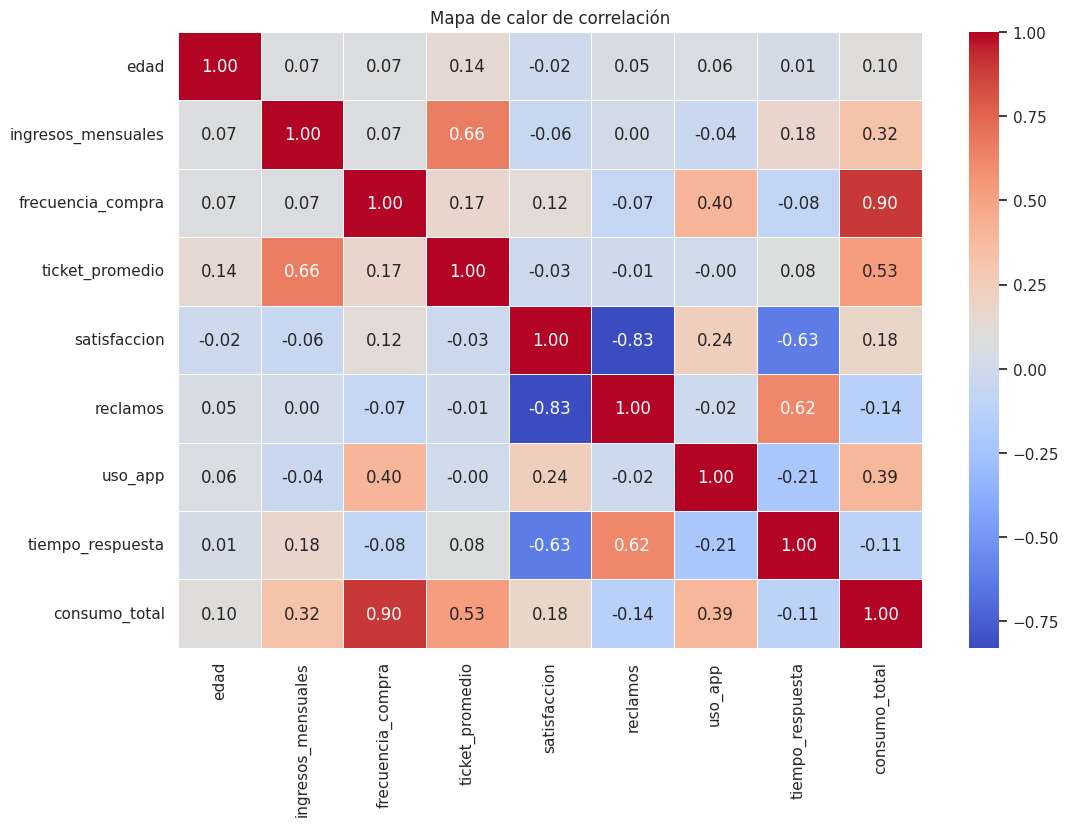

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de calor de correlación")
plt.show()

El mapa de calor facilita la identificación visual de relaciones positivas y negativas entre variables. Los valores cercanos a 1 indican correlación positiva fuerte, los cercanos a -1 indican correlación negativa fuerte y los cercanos a 0 sugieren relación débil o nula.

In [12]:
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Variable_1", "Variable_2", "Correlacion"]

corr_pairs = corr_pairs[corr_pairs["Variable_1"] != corr_pairs["Variable_2"]]

corr_pairs["Par"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["Variable_1"], row["Variable_2"]])), axis=1
)

corr_pairs = corr_pairs.drop_duplicates(subset="Par").drop(columns="Par")

corr_positivas = corr_pairs.sort_values(by="Correlacion", ascending=False)
corr_negativas = corr_pairs.sort_values(by="Correlacion", ascending=True)

print("Top 10 correlaciones positivas:")
display(corr_positivas.head(10))

print("\nTop 10 correlaciones negativas:")
display(corr_negativas.head(10))

Top 10 correlaciones positivas:


,Variable_1,Variable_2,Correlacion
26,frecuencia_compra,consumo_total,0.897235
12,ingresos_mensuales,ticket_promedio,0.659962
52,reclamos,tiempo_respuesta,0.620222
35,ticket_promedio,consumo_total,0.527335
24,frecuencia_compra,uso_app,0.400843
62,uso_app,consumo_total,0.394528
17,ingresos_mensuales,consumo_total,0.321616
42,satisfaccion,uso_app,0.240149
44,satisfaccion,consumo_total,0.179054
16,ingresos_mensuales,tiempo_respuesta,0.175441



Top 10 correlaciones negativas:


,Variable_1,Variable_2,Correlacion
41,satisfaccion,reclamos,-0.829002
43,satisfaccion,tiempo_respuesta,-0.625280
61,uso_app,tiempo_respuesta,-0.213356
53,reclamos,consumo_total,-0.141421
71,tiempo_respuesta,consumo_total,-0.114844
25,frecuencia_compra,tiempo_respuesta,-0.083792
23,frecuencia_compra,reclamos,-0.068936
13,ingresos_mensuales,satisfaccion,-0.056680
15,ingresos_mensuales,uso_app,-0.040493
31,ticket_promedio,satisfaccion,-0.028190


Aquí se ordenan los pares de variables para identificar las correlaciones positivas más importantes y las negativas más importantes

In [13]:
top4_pos = corr_positivas.head(4).copy()
top4_neg = corr_negativas.head(4).copy()

print("Correlaciones positivas más importantes:")
display(top4_pos)

print("Correlaciones negativas más importantes:")
display(top4_neg)

Correlaciones positivas más importantes:


,Variable_1,Variable_2,Correlacion
26,frecuencia_compra,consumo_total,0.897235
12,ingresos_mensuales,ticket_promedio,0.659962
52,reclamos,tiempo_respuesta,0.620222
35,ticket_promedio,consumo_total,0.527335


Correlaciones negativas más importantes:


,Variable_1,Variable_2,Correlacion
41,satisfaccion,reclamos,-0.829002
43,satisfaccion,tiempo_respuesta,-0.625280
61,uso_app,tiempo_respuesta,-0.213356
53,reclamos,consumo_total,-0.141421


Se muestran de forma separada las relaciones positivas y negativas más destacadas.

In [14]:
for i, row in top4_pos.iterrows():
    print(f"Relación positiva: {row['Variable_1']} y {row['Variable_2']} -> correlación = {row['Correlacion']:.3f}")

print("-" * 100)

for i, row in top4_neg.iterrows():
    print(f"Relación negativa: {row['Variable_1']} y {row['Variable_2']} -> correlación = {row['Correlacion']:.3f}")

Relación positiva: frecuencia_compra y consumo_total -> correlación = 0.897
Relación positiva: ingresos_mensuales y ticket_promedio -> correlación = 0.660
Relación positiva: reclamos y tiempo_respuesta -> correlación = 0.620
Relación positiva: ticket_promedio y consumo_total -> correlación = 0.527
----------------------------------------------------------------------------------------------------
Relación negativa: satisfaccion y reclamos -> correlación = -0.829
Relación negativa: satisfaccion y tiempo_respuesta -> correlación = -0.625
Relación negativa: uso_app y tiempo_respuesta -> correlación = -0.213
Relación negativa: reclamos y consumo_total -> correlación = -0.141


Interpretación de relaciones encontradas

1. Una correlación positiva alta entre frecuencia_compra y consumo_total indica que, a medida que un cliente compra más seguido, también aumenta su gasto acumulado. Esto puede ayudar a identificar clientes de alto valor para estrategias de fidelización.

2. Una correlación positiva entre ticket_promedio y consumo_total sugiere que los clientes que gastan más por compra también tienden a generar un mayor consumo total para la empresa.

3. Si existe correlación positiva entre uso_app y frecuencia_compra, puede interpretarse que los clientes que usan más la aplicación también compran con mayor frecuencia. Esto puede apoyar decisiones para fortalecer el canal digital.

4. Si se observa una correlación negativa entre reclamos y satisfaccion, significa que a mayor cantidad de reclamos, menor satisfacción del cliente. Esta relación es importante para mejorar la experiencia de servicio.

5. Si aparece una correlación negativa entre tiempo_respuesta y satisfaccion, se puede interpretar que tiempos de atención más largos afectan negativamente la percepción del cliente.